# Previsão da Qualidade de Vinhos — Classificação Multi-Classe
### KNN vs Random Forest

**Dataset:** Wine Quality (merged, Kaggle/UCI) — 6.497 amostras, vinho tinto e branco combinados.
**Target:** `quality` (nota 3-9), agrupada em 3 categorias: **Ruim** (≤4), **Médio** (5-6), **Bom** (≥7).
**Modelos comparados:** K-Nearest Neighbors (Modelo A) e Random Forest (Modelo B).

## 1. Setup e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score, accuracy_score,
                              precision_score, recall_score, roc_curve, auc)

sns.set_style("whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("wine_quality_merged.csv")
print("Shape:", df.shape)
df.head()

Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 2. Análise Exploratória de Dados (EDA)

### 2.1. Descrição geral, tipos de dados e valores ausentes

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [3]:
print("Valores ausentes por coluna:")
print(df.isna().sum())
print("\nTotal de valores ausentes no dataset:", df.isna().sum().sum())

Valores ausentes por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Total de valores ausentes no dataset: 0


**Conclusão:** o dataset não possui nenhum valor ausente (NaN). Por isso, nenhuma estratégia de imputação (média, mediana, moda ou remoção) é necessária nesta etapa — o item "Tratamento de Nulos" do pipeline está satisfeito por constatação, não por transformação.

### 2.2. Duplicatas

In [4]:
n_dup = df.duplicated().sum()
print(f"Linhas duplicadas: {n_dup} ({n_dup/len(df):.1%} do total)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape após remoção de duplicatas: {df.shape}")

Linhas duplicadas: 1177 (18.1% do total)
Shape após remoção de duplicatas: (5320, 13)


O dataset possui um número relevante de linhas duplicadas. Elas são removidas **antes** da divisão treino/validação/teste — se não fizermos isso, a mesma amostra pode acabar em duas partições diferentes (ex: treino e teste), inflando artificialmente as métricas de avaliação (vazamento de dados / *data leakage*).

### 2.3. Distribuição da variável alvo original (`quality`)

quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64


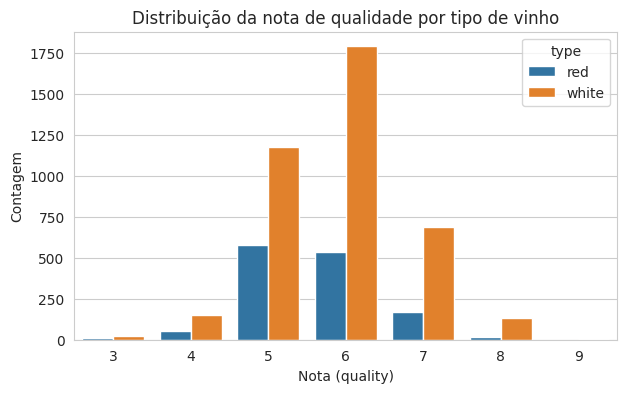

In [5]:
print(df["quality"].value_counts().sort_index())

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="quality", hue="type")
plt.title("Distribuição da nota de qualidade por tipo de vinho")
plt.xlabel("Nota (quality)")
plt.ylabel("Contagem")
plt.show()

### 2.4. Distribuição dos atributos numéricos e quantificação de outliers

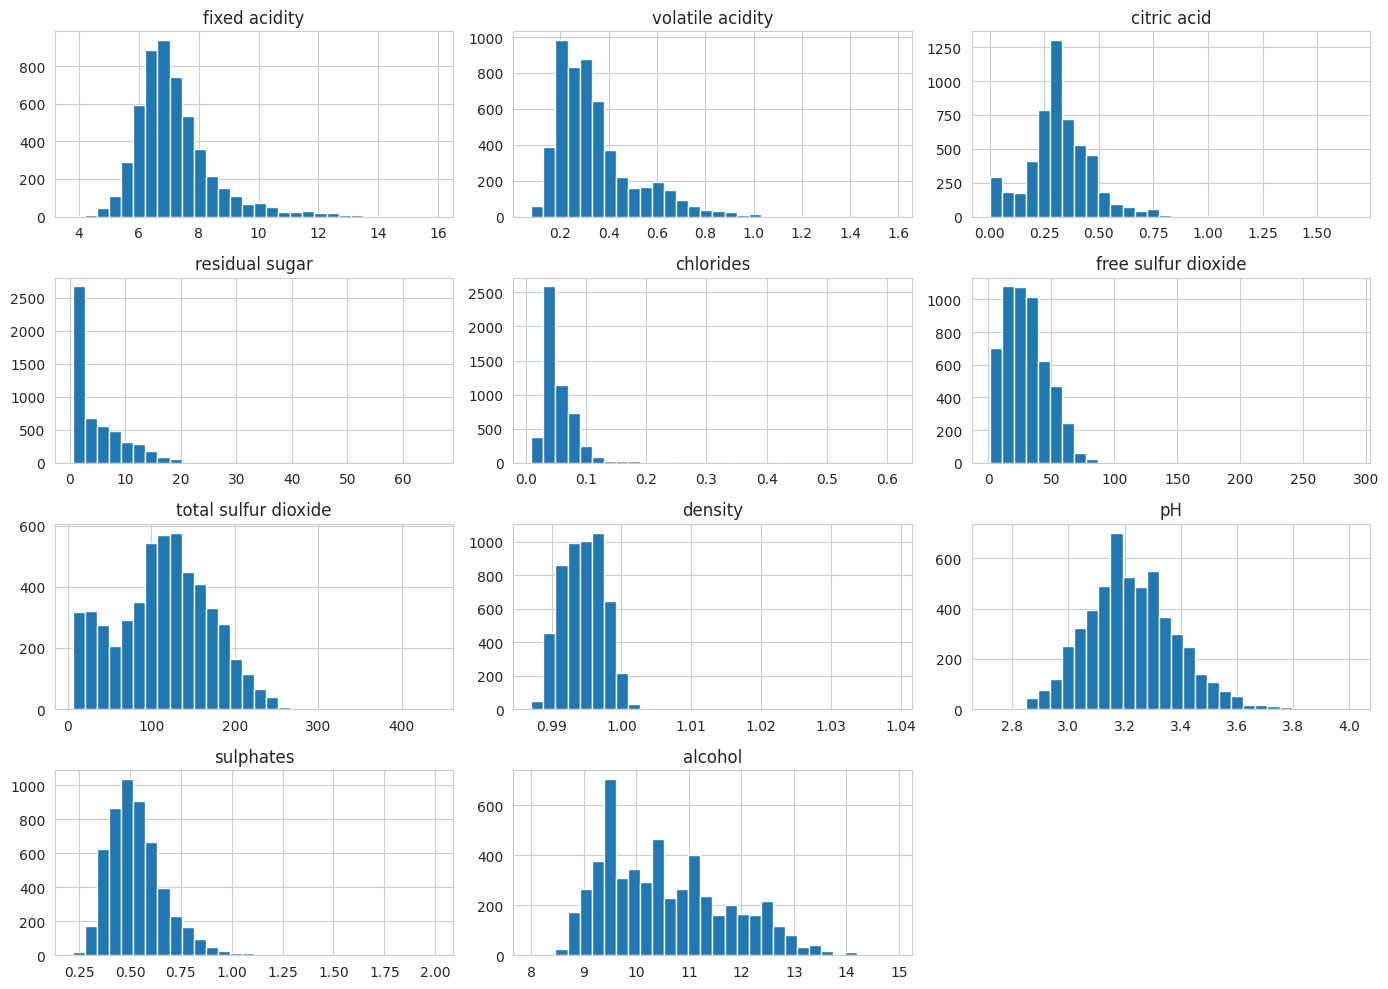

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop("quality")

df[num_cols].hist(bins=30, figsize=(14, 10))
plt.tight_layout()
plt.show()

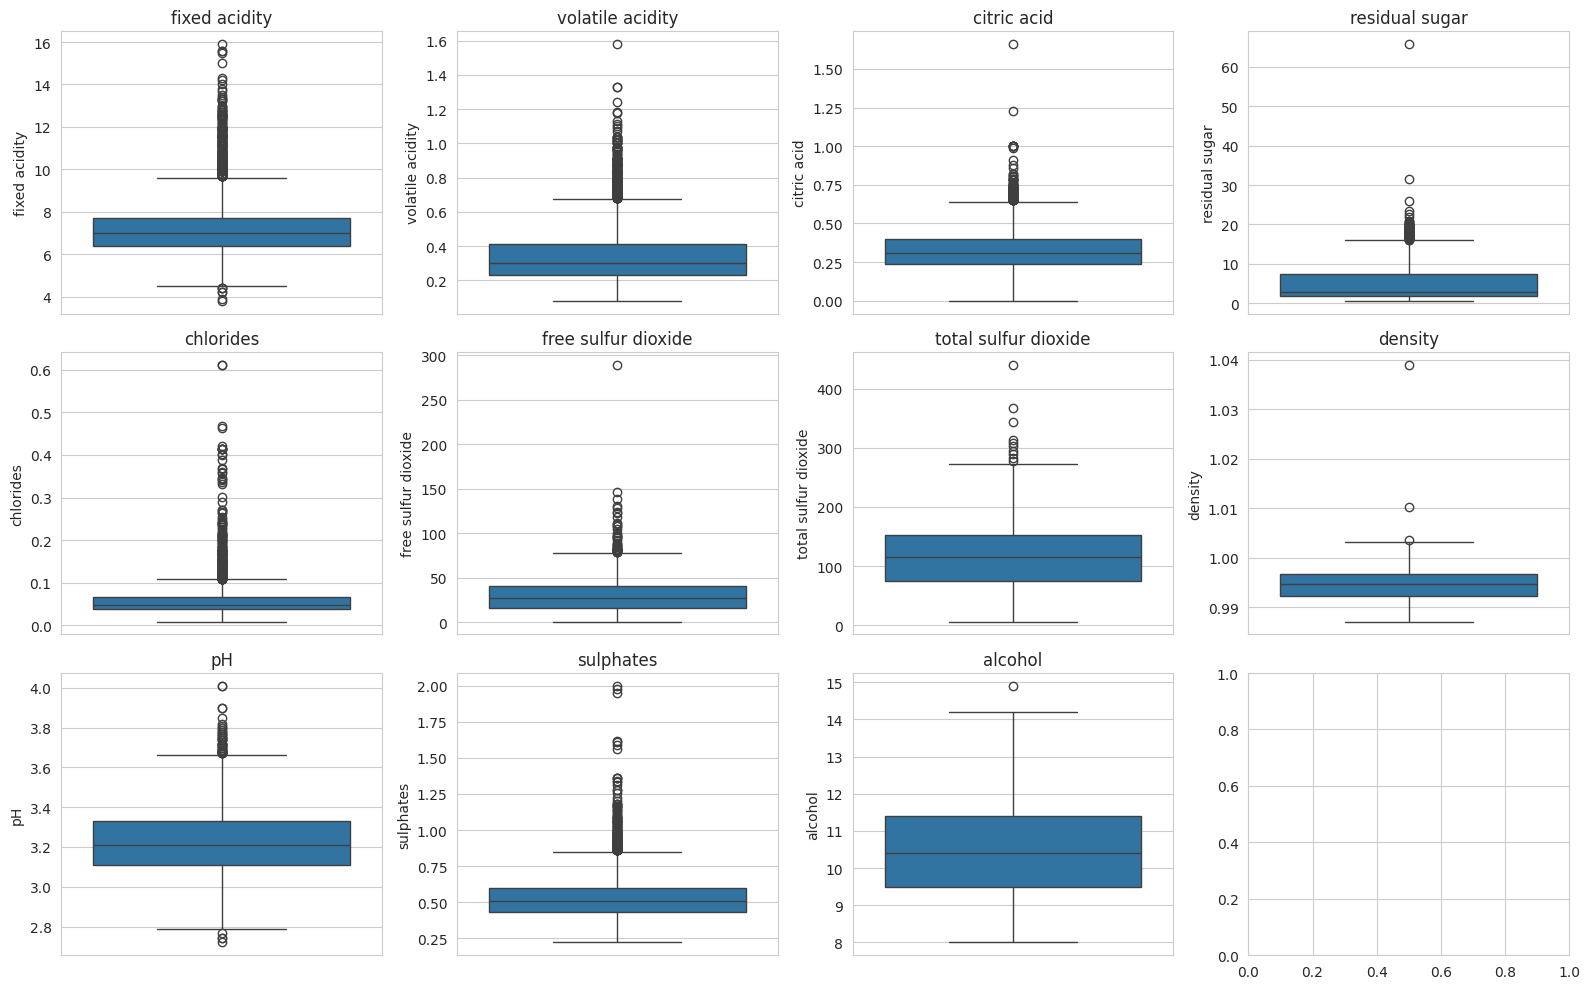

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [8]:
# Quantificação numérica de outliers pela regra do IQR (1.5x)
outlier_counts = {}
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

outlier_df = pd.Series(outlier_counts).sort_values(ascending=False)
print("Outliers por coluna (regra IQR 1.5x):")
print(outlier_df)
print(f"\nTotal de valores marcados como outlier (colunas podem se sobrepor): {outlier_df.sum()}")

Outliers por coluna (regra IQR 1.5x):
fixed acidity           304
volatile acidity        279
chlorides               237
sulphates               163
citric acid             143
residual sugar          141
pH                       49
free sulfur dioxide      44
total sulfur dioxide     10
density                   3
alcohol                   1
dtype: int64

Total de valores marcados como outlier (colunas podem se sobrepor): 1374


**Decisão sobre os outliers:** optamos por **não remover** esses valores extremos. No domínio de vinhos, atributos físico-químicos fora da faixa típica (ex: `residual sugar` ou `chlorides` muito altos) costumam corresponder a vinhos genuinamente atípicos — como vinhos de sobremesa muito doces — e não a erros de medição. Removê-los reduziria a capacidade dos modelos de generalizar para esses casos legítimos, especialmente para as classes minoritárias ("Ruim" e parte de "Bom"), que já são escassas.

### 2.5. Correlação com a variável alvo

quality                 1.000000
alcohol                 0.469422
citric acid             0.097954
free sulfur dioxide     0.054002
sulphates               0.041884
pH                      0.039733
total sulfur dioxide   -0.050296
residual sugar         -0.056830
fixed acidity          -0.080092
chlorides              -0.202137
volatile acidity       -0.265205
density                -0.326434
Name: quality, dtype: float64


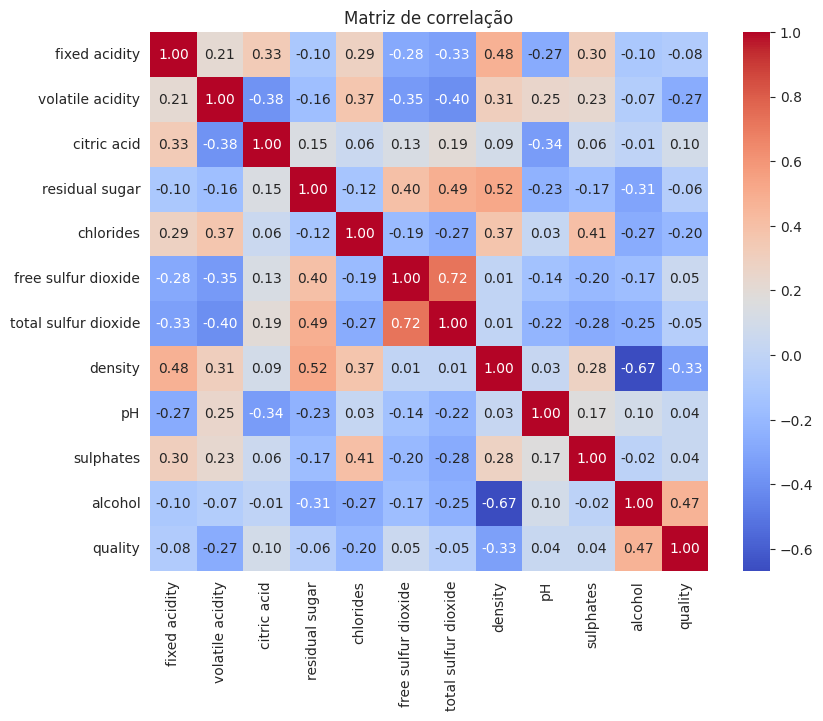

In [9]:
corr = df.corr(numeric_only=True)["quality"].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlação")
plt.show()

> **Observação para o relatório:** o teor alcoólico (`alcohol`) é o atributo com maior correlação positiva com a qualidade, enquanto `density` e `volatile acidity` apresentam correlação negativa — discutir esses achados na Fundamentação Teórica (Seção 1.3.3.2) e na Análise Crítica (Seção 1.5.4).

## 3. Definição da variável alvo (binning)

Convertendo a nota contínua (3-9) em 3 categorias:
- **Ruim:** nota ≤ 4
- **Médio:** nota 5-6
- **Bom:** nota ≥ 7

quality_class
Ruim      236
Médio    4075
Bom      1009
Name: count, dtype: int64

quality_class
Ruim      4.4 %
Médio    76.6 %
Bom      19.0 %
Name: count, dtype: str


/tmp/ipykernel_556/3875375550.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="quality_class", order=order, palette="viridis")


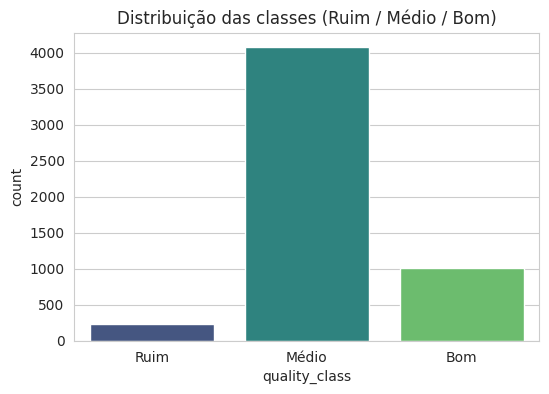

In [10]:
def bin_quality(q):
    if q <= 4:
        return "Ruim"
    elif q <= 6:
        return "Médio"
    else:
        return "Bom"

df["quality_class"] = df["quality"].apply(bin_quality)

order = ["Ruim", "Médio", "Bom"]
counts = df["quality_class"].value_counts().reindex(order)
print(counts)
print()
print((counts / len(df) * 100).round(1).astype(str) + " %")

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="quality_class", order=order, palette="viridis")
plt.title("Distribuição das classes (Ruim / Médio / Bom)")
plt.show()

**Diagnóstico de desbalanceamento:** as classes ficam fortemente desbalanceadas — "Médio" concentra a maior parte das amostras, enquanto "Ruim" fica com uma fração pequena. Por isso, nas próximas etapas: usamos `stratify` em todas as divisões dos dados, `class_weight='balanced'` na Random Forest, e priorizamos **F1-Score (macro)** — em vez de Accuracy pura — como métrica de otimização e de decisão, já que a Accuracy tenderia a mascarar o desempenho ruim nas classes minoritárias.

## 4. Engenharia de Atributos (Feature Engineering)

Criamos três novas colunas a partir de combinações de atributos existentes, com justificativa físico-química/estatística:

- **`total_acidity`** = `fixed acidity` + `volatile acidity` — acidez total percebida no vinho, em vez de olhar as duas componentes isoladamente.
- **`free_sulfur_ratio`** = `free sulfur dioxide` / `total sulfur dioxide` — a **proporção** de SO₂ livre (disponível para preservação) sobre o total costuma ser mais informativa quimicamente do que o valor absoluto de SO₂ livre sozinho.
- **`alcohol_density_ratio`** = `alcohol` / `density` — combina os dois atributos com maior correlação (positiva e negativa) com a qualidade em uma única variável de interação.

In [11]:
df["total_acidity"] = df["fixed acidity"] + df["volatile acidity"]

df["free_sulfur_ratio"] = df["free sulfur dioxide"] / df["total sulfur dioxide"].replace(0, np.nan)
df["free_sulfur_ratio"] = df["free_sulfur_ratio"].fillna(0)

df["alcohol_density_ratio"] = df["alcohol"] / df["density"]

new_features = ["total_acidity", "free_sulfur_ratio", "alcohol_density_ratio"]
print("Novas colunas criadas:", new_features)
df[new_features].describe()

Novas colunas criadas: ['total_acidity', 'free_sulfur_ratio', 'alcohol_density_ratio']


,total_acidity,free_sulfur_ratio,alcohol_density_ratio
count,5320.000000,5320.000000,5320.000000
mean,7.559308,0.287000,10.609678
std,1.365724,0.125970,1.214981
min,4.110000,0.022727,8.025038
25%,6.690000,0.201073,9.546348
50%,7.280000,0.269021,10.445962
75%,8.080000,0.350107,11.453401
max,16.285000,0.857143,14.935846


## 5. Divisão treino / validação / teste (70/15/15, estratificada)

Usamos três partições, não apenas duas:
- **Treino (70%):** usado pelo `GridSearchCV` (com validação cruzada interna de 5 folds) para ajustar hiperparâmetros.
- **Validação (15%):** usada como uma checagem independente do modelo já otimizado, **antes** de tocar no conjunto de teste — serve para detectar overfitting aos folds de validação cruzada do treino.
- **Teste (15%):** usado **uma única vez**, ao final, para a comparação oficial entre os Modelos A e B — é a estimativa não-viesada de desempenho em dados nunca vistos.

Todas as divisões usam `stratify` para preservar a proporção das classes (Ruim/Médio/Bom), dado o desbalanceamento identificado na Seção 3.

In [12]:
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, " Validação:", X_val.shape, " Teste:", X_test.shape)

Treino: (3724, 15)  Validação: (798, 15)  Teste: (798, 15)


## 6. Pré-processamento

- **Numéricas:** `StandardScaler` — essencial para o KNN, que é baseado em distância euclidiana/manhattan; sem padronização, atributos em escalas maiores (ex: `total sulfur dioxide`, na casa das centenas) dominariam o cálculo de distância sobre atributos em escalas menores (ex: `chlorides`, na casa de milésimos).
- **Categórica (`type`: red/white):** `OneHotEncoding` (com `drop="if_binary"`, já que é uma variável binária).

O `ColumnTransformer` é encapsulado dentro do `Pipeline` de cada modelo, garantindo que o `fit` do scaler e do encoder aconteça **somente** com dados de treino em cada fold do `GridSearchCV` — evitando vazamento de dados (*data leakage*).

In [13]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="if_binary"), categorical_features),
    ]
)

## 7. Modelo A — KNN (com otimização de hiperparâmetros)

In [14]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11, 15],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"],
}

knn_grid = GridSearchCV(knn_pipeline, knn_param_grid, cv=5,
                         scoring="f1_macro", n_jobs=-1)
knn_grid.fit(X_train, y_train)

print("Melhores hiperparâmetros (KNN):", knn_grid.best_params_)
print("Melhor F1-macro (validação cruzada no treino):", round(knn_grid.best_score_, 4))

Melhores hiperparâmetros (KNN): {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
Melhor F1-macro (validação cruzada no treino): 0.5091


## 8. Modelo B — Random Forest (com otimização de hiperparâmetros)

In [15]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE,
                                           class_weight="balanced"))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5,
                        scoring="f1_macro", n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Melhores hiperparâmetros (Random Forest):", rf_grid.best_params_)
print("Melhor F1-macro (validação cruzada no treino):", round(rf_grid.best_score_, 4))

Melhores hiperparâmetros (Random Forest): {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 300}
Melhor F1-macro (validação cruzada no treino): 0.5277


In [16]:
best_knn = knn_grid.best_estimator_
best_rf = rf_grid.best_estimator_

## 9. Checagem no conjunto de VALIDAÇÃO

Antes de tocar no conjunto de teste, avaliamos os modelos já otimizados no conjunto de validação — uma checagem independente dos folds usados pelo `GridSearchCV`. **Este não é o resultado final** (esse vem na Seção 10, com o conjunto de teste); serve apenas para confirmar que os modelos generalizam de forma consistente antes da avaliação oficial.

In [17]:
def summarize(y_true, y_pred, model_name):
    return {
        "Modelo": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Precision (macro)": round(precision_score(y_true, y_pred, average="macro"), 3),
        "Recall (macro)": round(recall_score(y_true, y_pred, average="macro"), 3),
        "F1-Score (macro)": round(f1_score(y_true, y_pred, average="macro"), 3),
    }

val_results = pd.DataFrame([
    summarize(y_val, best_knn.predict(X_val), "KNN"),
    summarize(y_val, best_rf.predict(X_val), "Random Forest"),
])
val_results

,Modelo,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,KNN,0.796,0.616,0.511,0.538
1,Random Forest,0.748,0.520,0.528,0.507


## 10. Avaliação final no conjunto de TESTE

Esta é a comparação oficial entre os dois modelos, feita **uma única vez**, sobre dados que nenhum dos dois modelos viu durante o treino ou a otimização de hiperparâmetros.

In [18]:
y_pred_knn = best_knn.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

print("=" * 60)
print("MODELO A — KNN")
print("=" * 60)
print(classification_report(y_test, y_pred_knn, digits=3))

print("=" * 60)
print("MODELO B — Random Forest")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, digits=3))

MODELO A — KNN


              precision    recall  f1-score   support

         Bom      0.518     0.467     0.491       152
       Médio      0.834     0.882     0.858       611
        Ruim      0.400     0.171     0.240        35

    accuracy                          0.772       798
   macro avg      0.584     0.507     0.530       798
weighted avg      0.755     0.772     0.761       798

MODELO B — Random Forest
              precision    recall  f1-score   support

         Bom      0.472     0.724     0.571       152
       Médio      0.879     0.795     0.835       611
        Ruim      0.667     0.229     0.340        35

    accuracy                          0.757       798
   macro avg      0.673     0.583     0.582       798
weighted avg      0.792     0.757     0.763       798



### 10.1. Tabela-resumo de métricas (para colar no relatório)

In [19]:
results = pd.DataFrame([
    summarize(y_test, y_pred_knn, "KNN"),
    summarize(y_test, y_pred_rf, "Random Forest"),
])
results

,Modelo,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,KNN,0.772,0.584,0.507,0.530
1,Random Forest,0.757,0.673,0.583,0.582


**Justificativa das métricas escolhidas:** dado o desbalanceamento de classes (Seção 3), a Accuracy pura pode ser enganosa — um modelo que sempre prevê "Médio" já acertaria a maior parte das amostras sem aprender nada útil sobre "Ruim" ou "Bom". Por isso, priorizamos **Precision, Recall e F1-Score em média macro**, que tratam as três classes com peso igual, independentemente do tamanho de cada uma — essa é a métrica mais adequada para decidir qual modelo é melhor neste problema.

### 10.2. Matrizes de Confusão

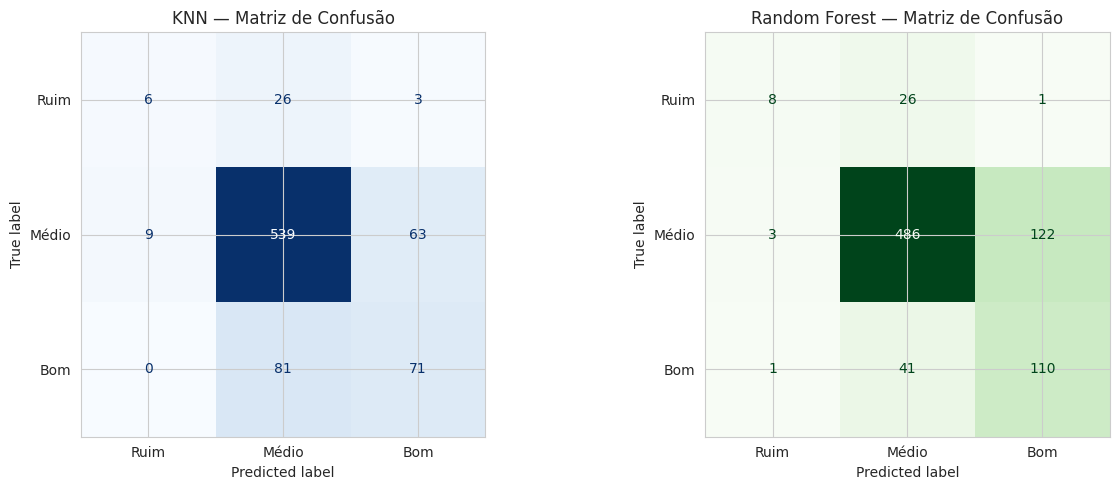

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, labels=order,
                                         ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("KNN — Matriz de Confusão")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, labels=order,
                                         ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Random Forest — Matriz de Confusão")

plt.tight_layout()
plt.show()

### 10.3. Curva ROC (multi-classe, estratégia one-vs-rest)

Como o problema tem 3 classes, não existe uma única curva ROC — construímos uma curva por classe, tratando cada uma como "essa classe" vs. "todas as outras" (*one-vs-rest*), e reportamos a AUC de cada uma.

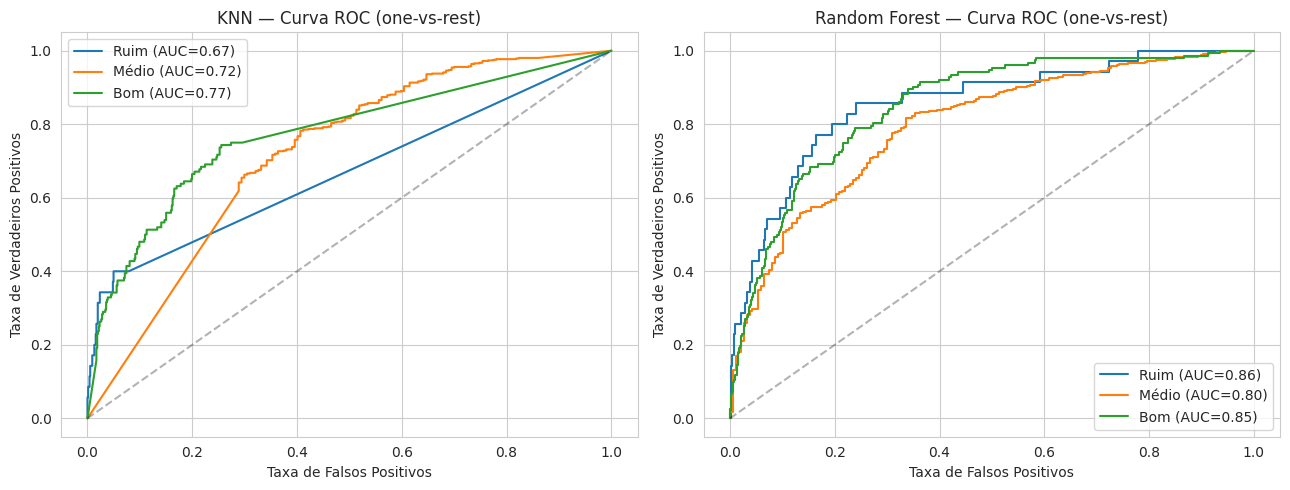

In [21]:
y_test_bin = label_binarize(y_test, classes=order)
proba_knn = best_knn.predict_proba(X_test)
proba_rf = best_rf.predict_proba(X_test)

knn_classes = list(best_knn.named_steps["classifier"].classes_)
rf_classes = list(best_rf.named_steps["classifier"].classes_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, cls in enumerate(order):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_knn[:, knn_classes.index(cls)])
    axes[0].plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("KNN — Curva ROC (one-vs-rest)")
axes[0].set_xlabel("Taxa de Falsos Positivos")
axes[0].set_ylabel("Taxa de Verdadeiros Positivos")
axes[0].legend()

for i, cls in enumerate(order):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_rf[:, rf_classes.index(cls)])
    axes[1].plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("Random Forest — Curva ROC (one-vs-rest)")
axes[1].set_xlabel("Taxa de Falsos Positivos")
axes[1].set_ylabel("Taxa de Verdadeiros Positivos")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Feature Importance (Random Forest)

A Random Forest permite extrair diretamente a importância de cada atributo na decisão do modelo — útil para discutir se as novas features criadas na Seção 4 realmente ajudaram.

/tmp/ipykernel_556/4151244009.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")


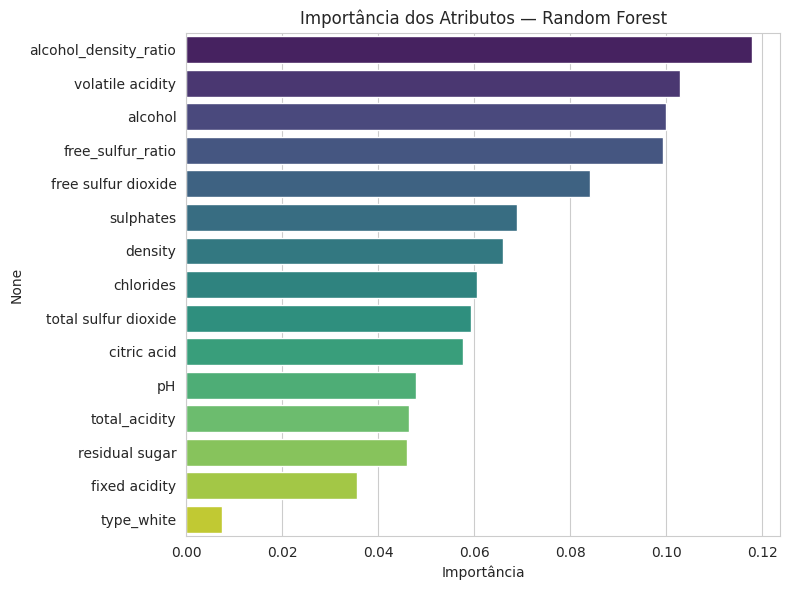

alcohol_density_ratio    0.117849
volatile acidity         0.102859
alcohol                  0.100003
free_sulfur_ratio        0.099302
free sulfur dioxide      0.084107
sulphates                0.068936
density                  0.066038
chlorides                0.060503
total sulfur dioxide     0.059408
citric acid              0.057612
pH                       0.047914
total_acidity            0.046465
residual sugar           0.046043
fixed acidity            0.035520
type_white               0.007440
dtype: float64

In [22]:
feature_names = (numeric_features +
    list(best_rf.named_steps["preprocessor"]
         .named_transformers_["cat"].get_feature_names_out(categorical_features)))

importances = best_rf.named_steps["classifier"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title("Importância dos Atributos — Random Forest")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

feat_imp

## 12. Conclusão (a ser completada pela dupla)

Preencham aqui, após rodar o notebook e observar os resultados acima:

- Qual modelo obteve o melhor F1-Score (macro) no teste (Seção 10.1)?
- O que a matriz de confusão revela sobre os erros de cada modelo (ex: confusão entre "Médio" e "Bom")?
- As curvas ROC (Seção 10.3) confirmam a mesma conclusão da tabela de métricas, ou há alguma classe em que um modelo se destaca mais que o outro?
- Quais atributos mais influenciaram a Random Forest (Seção 11)? As features criadas na Seção 4 (`total_acidity`, `free_sulfur_ratio`, `alcohol_density_ratio`) ficaram entre as mais importantes? Isso é coerente com a análise de correlação da Seção 2.5?
- Qual modelo vocês recomendariam para uso prático, considerando o trade-off entre desempenho e interpretabilidade (KNN é mais simples de explicar; Random Forest tende a performar melhor em cenários desbalanceados, mas é uma "caixa-preta" maior)?